
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 4 <br>
</div>


---



### Full Name : Kasra Siavashpour
### Student Number : 99109903
___

# Import Required Libraries

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score
# from sklearn.neural_network import MLPClassifier
# import os

# Dilation and Erosion

In [5]:

def dilate(image, structuring_element):
    """Binary dilation (no OpenCV!)"""
    img_h, img_w = image.shape
    se_h, se_w = structuring_element.shape
    pad_h, pad_w = se_h // 2, se_w // 2

    # Pad image
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    dilated = np.zeros_like(image)

    # Slide structuring element
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+se_h, j:j+se_w]
            if np.any(region[structuring_element == 1]):
                dilated[i, j] = 255
            else:
                dilated[i, j] = 0
    return dilated


In [6]:
def erode(image, structuring_element):
    """Binary erosion (no OpenCV!)"""
    img_h, img_w = image.shape
    se_h, se_w = structuring_element.shape
    pad_h, pad_w = se_h // 2, se_w // 2

    # Pad image
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    eroded = np.zeros_like(image)

    # Slide structuring element
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+se_h, j:j+se_w]
            # Erode: SE must fit entirely inside object
            if np.all(region[structuring_element == 1] == 255):
                eroded[i, j] = 255
            else:
                eroded[i, j] = 0
    return eroded

## Noise Reduction

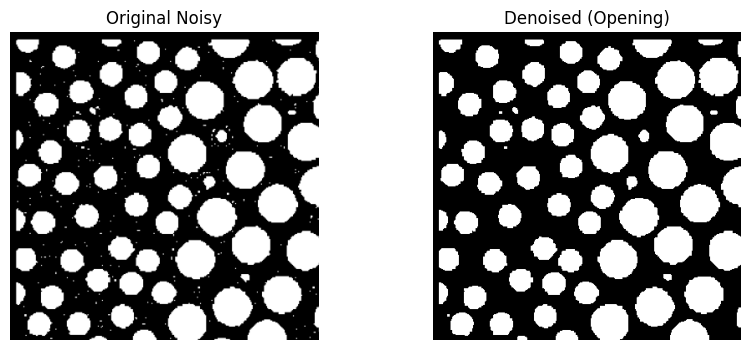

In [7]:


# Define a 3x3 square structuring element
se = np.ones((3, 3), dtype=np.uint8)

# Path to noisy image
path = "noisy_image.png"
noisy_image = cv2.imread(path, 0)

# Binarize if needed
_, binary_noisy = cv2.threshold(noisy_image, 127, 255, cv2.THRESH_BINARY)

# First, apply erosion to remove noise (pepper)
eroded = erode(binary_noisy, se)

# Then, apply dilation to restore shape (opening)
denoised = dilate(eroded, se)

# Show results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original Noisy")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Denoised (Opening)")
plt.imshow(denoised, cmap='gray')
plt.axis('off')
plt.show()

## Parallel Vertical Lines

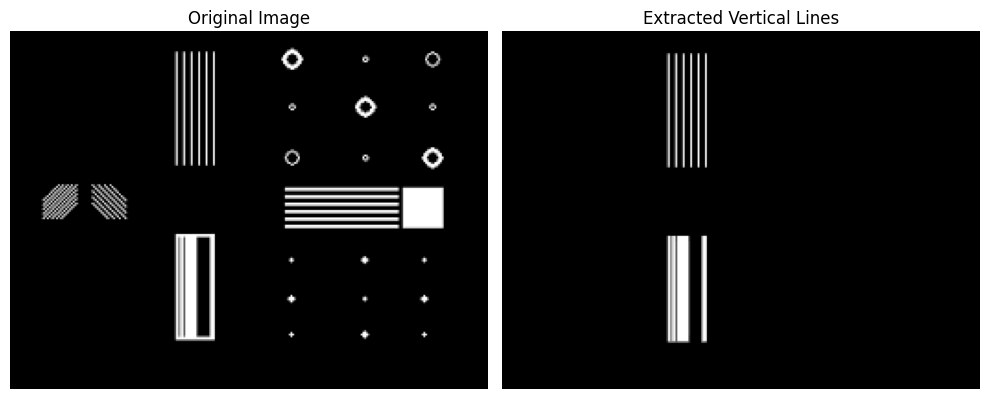

In [8]:
# Read Q2.png image
q2_image = cv2.imread('Q2.png', 0)

# Create vertical line structuring element
# Height should be larger than the gaps in vertical lines
vertical_se = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 30))

# Apply morphological operations to extract vertical lines
# First erode with vertical kernel to remove non-vertical elements
vertical_eroded = cv2.erode(q2_image, vertical_se, iterations=1)
# Then dilate to restore the vertical lines
vertical_lines = cv2.dilate(vertical_eroded, vertical_se, iterations=1)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(q2_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vertical_lines, cmap='gray')
plt.title('Extracted Vertical Lines')
plt.axis('off')

plt.tight_layout()
plt.show()

## Parallel Horizontal Lines

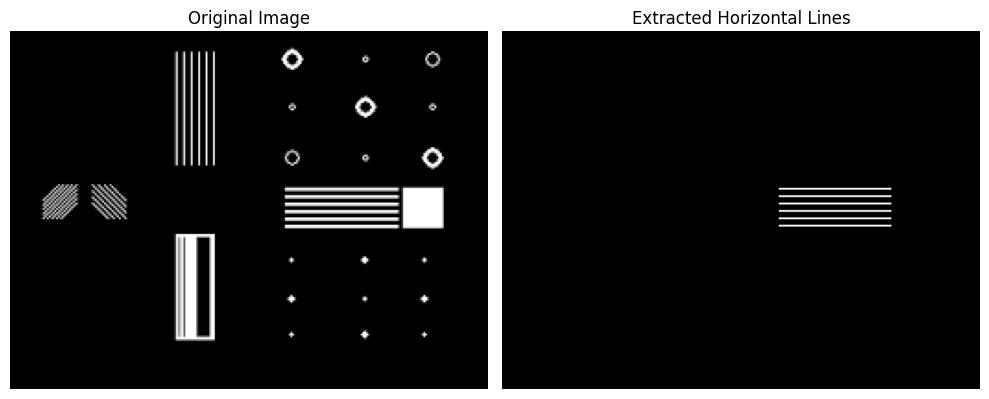

In [9]:
# Create horizontal line structuring element
# Width should be larger than the gaps in horizontal lines
horizontal_se = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))

# Apply morphological operations to extract horizontal lines
# First erode with horizontal kernel to remove non-horizontal elements
horizontal_eroded =erode(q2_image, horizontal_se)
# Then dilate to restore the horizontal lines
horizontal_lines = cv2.dilate(horizontal_eroded, horizontal_se, iterations=1)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(q2_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(horizontal_lines, cmap='gray')
plt.title('Extracted Horizontal Lines')
plt.axis('off')

plt.tight_layout()
plt.show()

## Edge Detecting

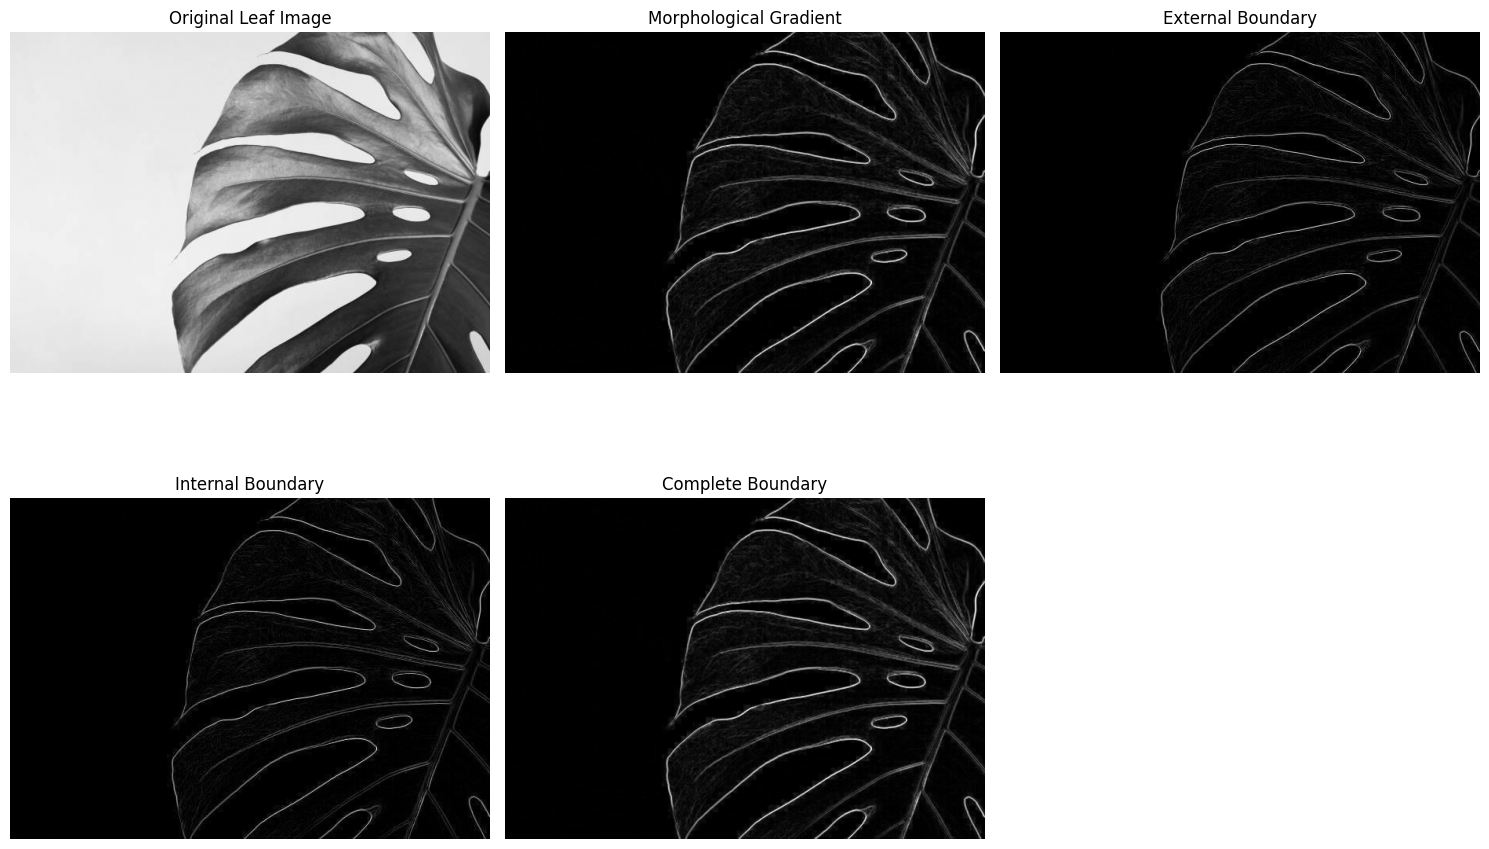

In [10]:
# Read leaf image
leaf_image = cv2.imread('leaf.jpg', 0)

# Method 1: Morphological Gradient (Dilation - Erosion)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
gradient = cv2.morphologyEx(leaf_image, cv2.MORPH_GRADIENT, kernel)

# Method 2: External Boundary (Original - Erosion)
erosion = cv2.erode(leaf_image, kernel, iterations=1)
external_boundary = cv2.subtract(leaf_image, erosion)

# Method 3: Internal Boundary (Dilation - Original)
dilation = cv2.dilate(leaf_image, kernel, iterations=1)
internal_boundary = cv2.subtract(dilation, leaf_image)

# Display results
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(leaf_image, cmap='gray')
plt.title('Original Leaf Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gradient, cmap='gray')
plt.title('Morphological Gradient')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(external_boundary, cmap='gray')
plt.title('External Boundary')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(internal_boundary, cmap='gray')
plt.title('Internal Boundary')
plt.axis('off')

# Combine boundaries for complete edge
complete_boundary = cv2.add(external_boundary, internal_boundary)
plt.subplot(2, 3, 5)
plt.imshow(complete_boundary, cmap='gray')
plt.title('Complete Boundary')
plt.axis('off')

plt.tight_layout()
plt.show()

# Counting Coins

In [11]:
path = 'coins.png'  # Path to coins image
coins = cv2.imread(path)

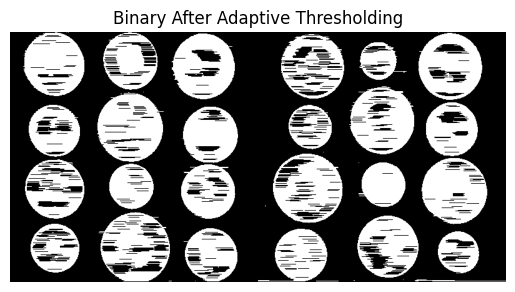

In [12]:
gray = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)

# Adaptive threshold (handles mixed brightness)
thresh = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 17, 11)

# Morphological closing to fill small holes in coins
kernel = np.ones((1,9), np.uint8)
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.imshow(closed, cmap='gray')
plt.title("Binary After Adaptive Thresholding")
plt.axis("off")
plt.show()

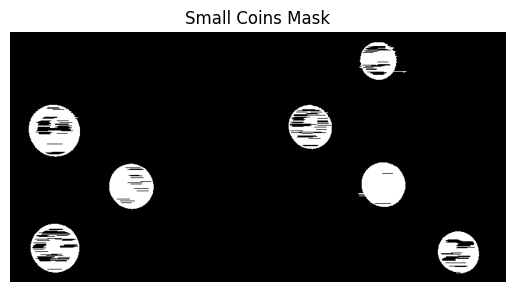

In [13]:
# Connected components with stats
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)

# Filter small coins by area
min_area = 500
max_area = 4500

small_mask = np.zeros_like(closed)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if min_area < area < max_area:
        small_mask[labels == i] = 255

plt.imshow(small_mask, cmap='gray')
plt.title("Small Coins Mask")
plt.axis("off")
plt.show()

Number of small coins: 7


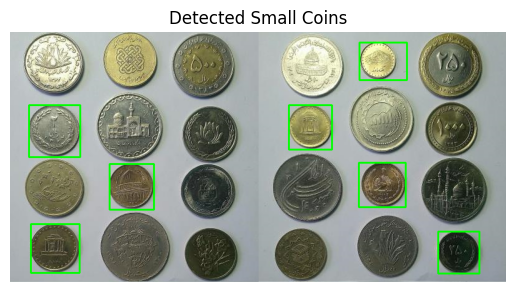

In [15]:
# Count again and draw
num_small, _, small_stats, _ = cv2.connectedComponentsWithStats(small_mask)

print("Number of small coins:", num_small - 1)

output = coins.copy()
for i in range(1, num_small):
    x, y, w, h, _ = small_stats[i]
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Small Coins")
plt.axis("off")
plt.show()

# Shape Descriptors

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import ListedColormap

Load the Images

In [32]:
image_dir = "Leaves"
image_files = [
    "autumn leaf (1).jpg", "autumn leaf (2).png", "autumn leaf (3).png",
    "banana leaf (1).jpg", "banana leaf (2).png", "banana leaf (3).png"
]

images = []
for file in image_files:
    img_path = os.path.join(image_dir, file)
    img = cv2.imread(img_path)
    if img is not None:
        images.append((file, img))
    else:
        print(f" Failed to load: {file}")

In [33]:
def extract_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None
    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h
    extent = area / (w * h)

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0

    return [aspect_ratio, extent, solidity, circularity], cnt, (x, y, w, h)

Extract Feature Vector for each Image

In [34]:
X_all = []
y = []
features = []

for name, img in images:
    feat, cnt, box = extract_features(img)
    if feat:
        X_all.append(feat)
        y.append(1 if "autumn" in name else 0)  # 1: autumn, 0: banana
        features.append((img, name, feat, cnt, box))

In [39]:
# Choose feature indices (0=aspect ratio, 1=extent, 2=solidity, 3=circularity)
f1_idx, f2_idx = 2, 3  # e.g., solidity vs circularity
X = [[feat[f1_idx], feat[f2_idx]] for feat in X_all]
feature_names = ["Aspect Ratio", "Extent", "Solidity", "Circularity"]
x_label = feature_names[f1_idx]
y_label = feature_names[f2_idx]
mlp = MLPClassifier(hidden_layer_sizes=(), max_iter=6000)
mlp.fit(X, y)
y_pred = mlp.predict(X)

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Classify by a Simple Model

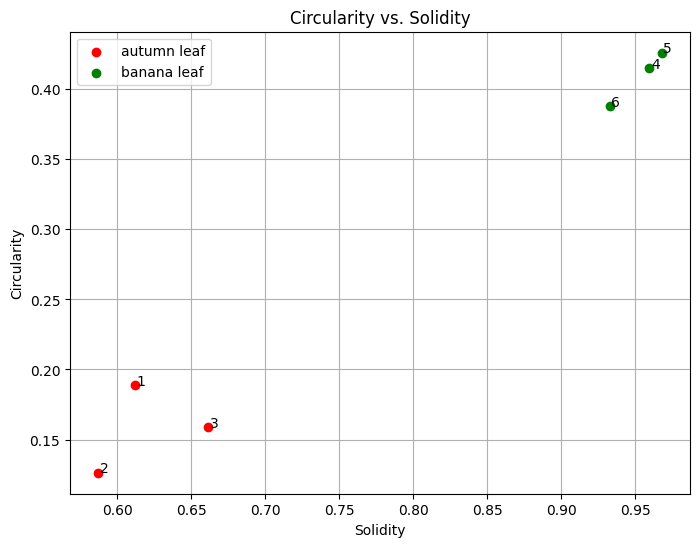

In [40]:
plt.figure(figsize=(8,6))
for i, (img, name, feat, _, _) in enumerate(features):
    color = 'red' if y[i] == 1 else 'green'
    label = "autumn leaf" if y[i] == 1 else "banana leaf"
    plt.scatter(X[i][0], X[i][1], color=color, label=label if label not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.text(X[i][0]+0.001, X[i][1], f"{i+1}")

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f"{y_label} vs. {x_label}")
plt.grid(True)
plt.legend()
plt.show()

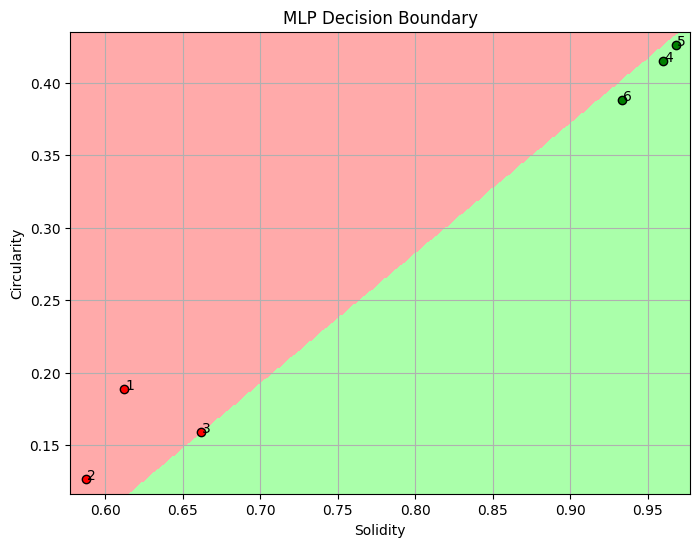

Accuracy: 0.8333333333333334


In [41]:
mlp = MLPClassifier(hidden_layer_sizes=(), max_iter=6000, random_state=42)
mlp.fit(X, y)
y_pred = mlp.predict(X)

accuracy = accuracy_score(y, y_pred)
X_np = np.array(X)
h = 0.001
x_min, x_max = X_np[:, 0].min() - 0.01, X_np[:, 0].max() + 0.01
y_min, y_max = X_np[:, 1].min() - 0.01, X_np[:, 1].max() + 0.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(["#aaffaa", "#ffaaaa"]))  # green/red background

for i in range(len(X)):
    color = 'green' if y[i] == 0 else 'red'
    plt.scatter(X[i][0], X[i][1], color=color, edgecolor='black')
    plt.text(X[i][0] + 0.001, X[i][1], f"{i+1}")

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("MLP Decision Boundary")
plt.grid(True)
plt.show()
print("Accuracy:", accuracy)